Matplotlib is building the font cache; this may take a moment.


Loading Hugging Face model and weights...


Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]


--- Starting PyTorch Hardware Latency Benchmark ---
Running warm-up passes...


model.safetensors: reconstructing file:   0%|          |  0.00B / 5.15MB            

model.safetensors: downloading bytes:           |  0.00B            

Benchmarking over 50 iterations...
Total time: 33214.44 ms
Average Latency: 664.29 ms per image
Throughput: 1.51 FPS
-------------------------------------------

==> Predicted Output: {281: 'tabby, tabby cat'}


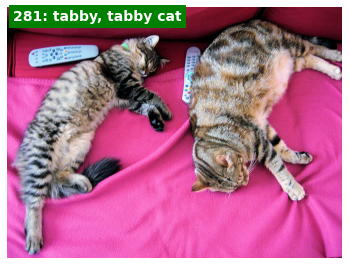

In [1]:
import os
import time
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image
from transformers import MobileViTImageProcessor, MobileViTForImageClassification

# 1. Optimize memory for edge device benchmarking
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
torch.set_grad_enabled(False)

# 2. Download test image
img_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
print("Downloading test image...")
image = Image.open(requests.get(img_url, stream=True).raw)

# 3. Load processor and PyTorch model
print("Loading Hugging Face model and weights...")
processor = MobileViTImageProcessor.from_pretrained("apple/mobilevit-xx-small")
model = MobileViTForImageClassification.from_pretrained(
    "apple/mobilevit-xx-small", 
    low_cpu_mem_usage=True
)
model.eval() # Ensure dropout and batchnorm are in inference mode

# Preprocess image once outside the loop (to benchmark just the model, like the MindSpore script)
inputs = processor(images=image, return_tensors="pt")

# 4. Latency Benchmark
print("\n--- Starting PyTorch Hardware Latency Benchmark ---")
print("Running warm-up passes...")
for _ in range(5):
    _ = model(**inputs)

num_iterations = 50
print(f"Benchmarking over {num_iterations} iterations...")

start_time = time.perf_counter()
for _ in range(num_iterations):
    outputs = model(**inputs)
end_time = time.perf_counter()

# Calculate metrics
total_time_ms = (end_time - start_time) * 1000
avg_latency_ms = total_time_ms / num_iterations
fps = 1000.0 / avg_latency_ms

print(f"Total time: {total_time_ms:.2f} ms")
print(f"Average Latency: {avg_latency_ms:.2f} ms per image")
print(f"Throughput: {fps:.2f} FPS")
print("-------------------------------------------\n")

# 5. Extract prediction & display
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
label_text = model.config.id2label[predicted_class_idx]

print(f"==> Predicted Output: {{{predicted_class_idx}: '{label_text}'}}")

# Render image with Matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.text(10, 25, f"{predicted_class_idx}: {label_text}", color='white', 
         fontsize=14, weight='bold', backgroundcolor='green')
plt.axis('off')
plt.show()